Crypto Arima Data Exploration

Martha McQuillan 1/12/2026

In [5]:
import sys
from pathlib import Path

# add project root to Python path
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# Data Loading

In [13]:
import matplotlib.pyplot as plt

from src.data_loader import (
    fetch_yahoo,
    make_price_df,
    compute_log_returns,
    save_prices_csv,
    load_prices_csv,
)

# 1) Fetch BTC-USD Series
btc = fetch_yahoo("BTC-USD", start="2018-01-01")
print("BTC series:")
print(btc.head(), "\n")

# 2) Fetch both BTC-USD and ETH-USD
prices = make_price_df(
    {"btc_usd": "BTC-USD", "eth_usd": "ETH-USD"},
    start="2018-01-01",
)
print("Prices DF:")
print(prices.head(), "\n")

# 3) Save prices to (project-root/data/)
path = save_prices_csv(prices, filename="btc_eth_prices.csv")
print("Saved prices to:", path, "\n")

# 4) Load them back
prices_loaded = load_prices_csv("btc_eth_prices.csv")
print("Loaded DF matches shape:", prices_loaded.shape, "\n")

# 5) Compute log returns
returns = compute_log_returns(prices_loaded)
print("Returns DF:")
print(returns.head(), "\n")

BTC series:
Date
2018-01-01    13657.200195
2018-01-02    14982.099609
2018-01-03    15201.000000
2018-01-04    15599.200195
2018-01-05    17429.500000
Freq: D, Name: BTC-USD, dtype: float64 

Prices DF:
                 btc_usd     eth_usd
Date                                
2018-01-01  13657.200195  772.640991
2018-01-02  14982.099609  884.443970
2018-01-03  15201.000000  962.719971
2018-01-04  15599.200195  980.921997
2018-01-05  17429.500000  997.719971 

Saved prices to: /Users/marthamcquillan/Projects/crypto-arima/data/btc_eth_prices.csv 

Loaded DF matches shape: (2935, 2) 

Returns DF:
            btc_usd_logret  eth_usd_logret
date                                      
2018-01-02        0.092589        0.135145
2018-01-03        0.014505        0.084803
2018-01-04        0.025858        0.018730
2018-01-05        0.110945        0.016980
2018-01-06        0.005578        0.043117 



# Price Behavior

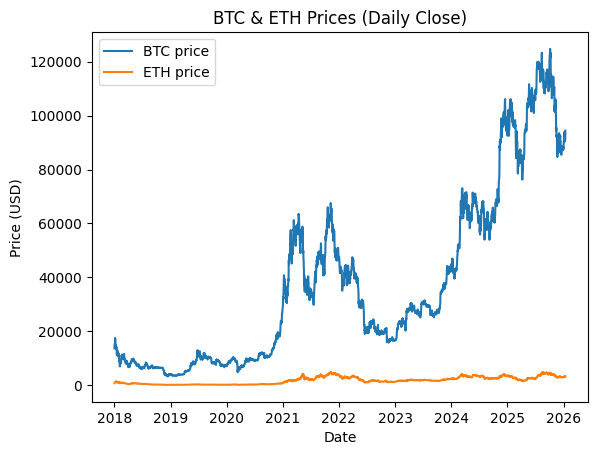

In [14]:
plt.plot(
    prices_loaded.index,
    prices_loaded["btc_usd"],
    label="BTC price",
)

plt.plot(
    prices_loaded.index,
    prices_loaded["eth_usd"],
    label="ETH price",
)

plt.title("BTC & ETH Prices (Daily Close)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

# Return Log Transformation

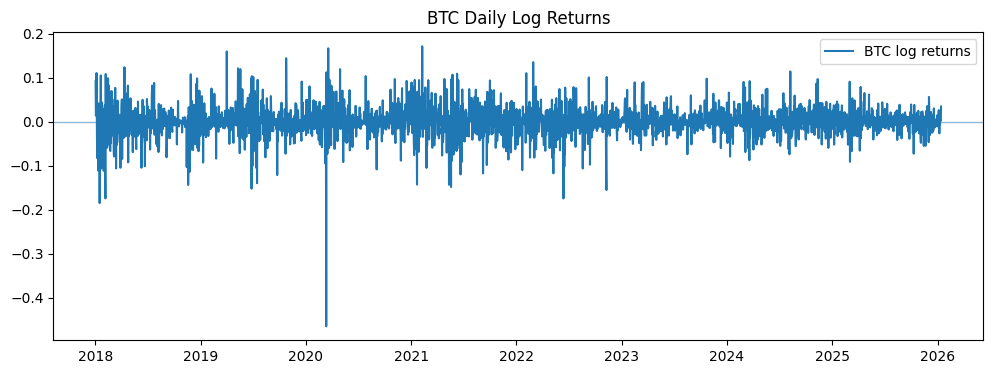

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(
    returns.index,
    returns["btc_usd_logret"],
    label="BTC log returns"
)
plt.axhline(0, linewidth=1, alpha=0.5)
plt.title("BTC Daily Log Returns")
plt.legend()
plt.show()


## Interpretation: 
## BTC log returns fluctuate around zero with no visible long-term trend, indicating stationarity in the mean. The series exhibits strong volatility clustering, with periods of calm followed by bursts of large movements. Several extreme negative returns are visible, reflecting possible crash events.

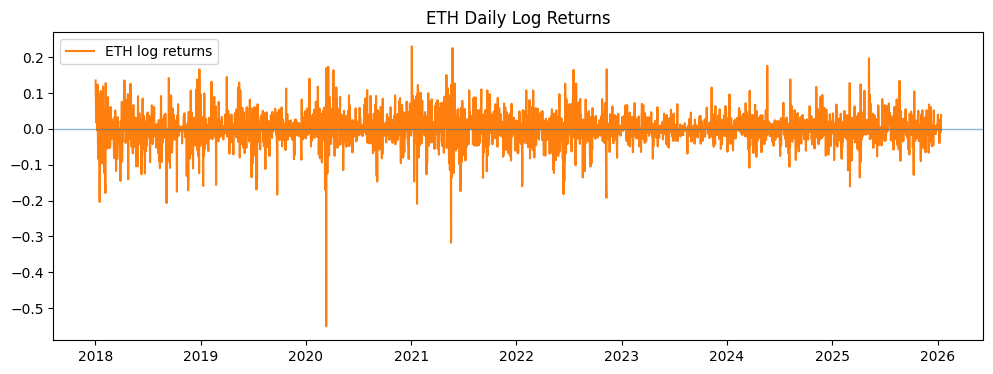

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(
    returns.index,
    returns["eth_usd_logret"],
    label="ETH log returns",
    color="tab:orange"

)
plt.axhline(0, linewidth=1, alpha=0.5)
plt.title("ETH Daily Log Returns")
plt.legend()
plt.show()

## Interpretation: 
## ETH log returns display similar behavior to BTC, remaining centered around zero. Large downside outliers appear more frequently, confirming that ETH carries greater short-term risk. Volatility clustering is clearly present, suggesting time-varying variance rather than constant dispersion.


# Log Return Diagrams and Analysis

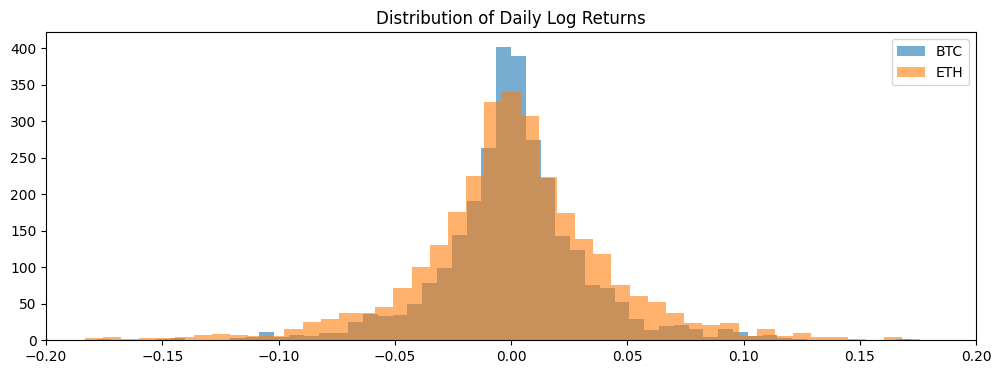

In [15]:
plt.figure(figsize=(12, 4))
plt.hist(returns["btc_usd_logret"], bins=100, alpha=0.6, label="BTC")
plt.hist(returns["eth_usd_logret"], bins=100, alpha=0.6, label="ETH")
plt.title("Distribution of Daily Log Returns")
plt.xlim(-0.2, 0.2) 
plt.legend()
plt.show()

## Interpretation: 
## BTC and ETH log returns are centered near zero but display heavy-tailed distributions, with ETH exhibiting greater dispersion. This indicates stationary returns with high volatility and non-Gaussian behavior.


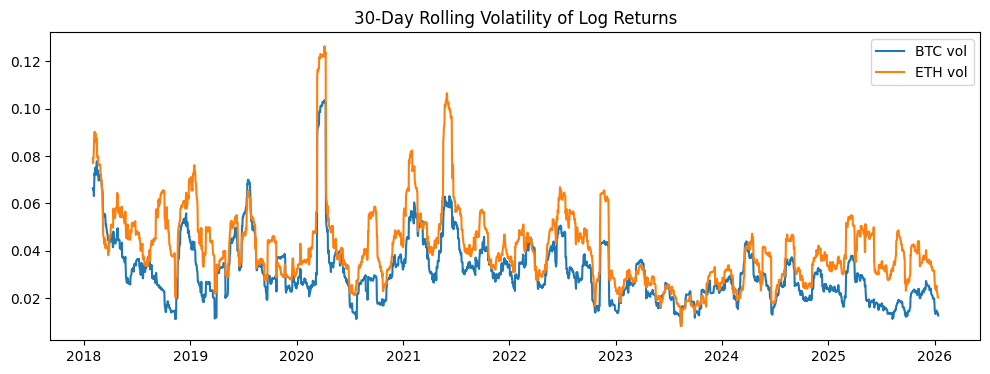

In [8]:
rolling_vol = returns.rolling(30).std()

plt.figure(figsize=(12, 4))
plt.plot(rolling_vol.index, rolling_vol["btc_usd_logret"], label="BTC vol")
plt.plot(rolling_vol.index, rolling_vol["eth_usd_logret"], label="ETH vol")
plt.title("30-Day Rolling Volatility of Log Returns")
plt.legend()
plt.show()

## Interpretation:
## Volatility for both BTC and ETH is highly time-varying, with pronounced clustering. ETH remains consistently more volatile than BTC, highlighting its overall higher risk. These patterns indicate strong conditional heteroskedasticity in crypto returns.


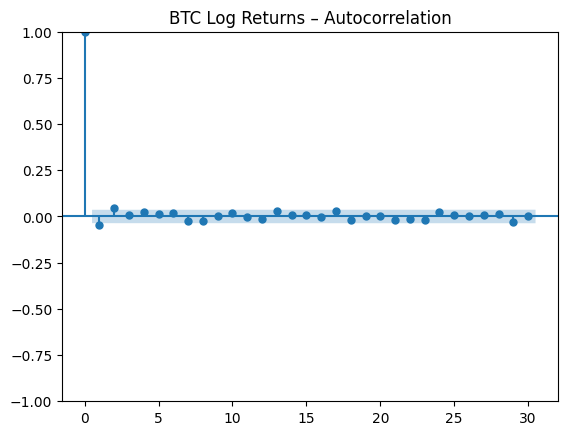

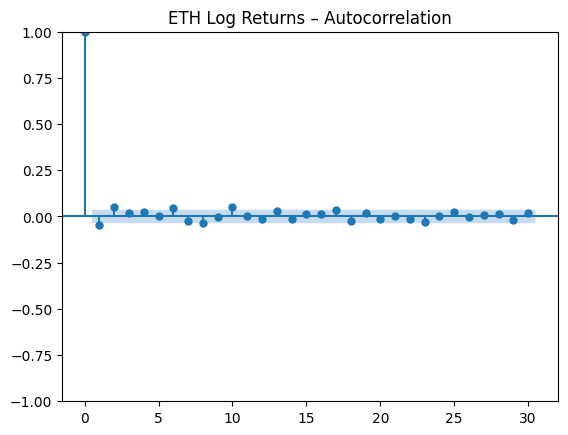

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(returns["btc_usd_logret"], lags=30)
plt.title("BTC Log Returns – Autocorrelation")
plt.show()

plot_acf(returns["eth_usd_logret"], lags=30)
plt.title("ETH Log Returns – Autocorrelation")
plt.show()

## Interpretation:
## Autocorrelation in BTC and ETH log returns is negligible across most lags, indicating weak linear predictability and near–white-noise behavior in daily returns.

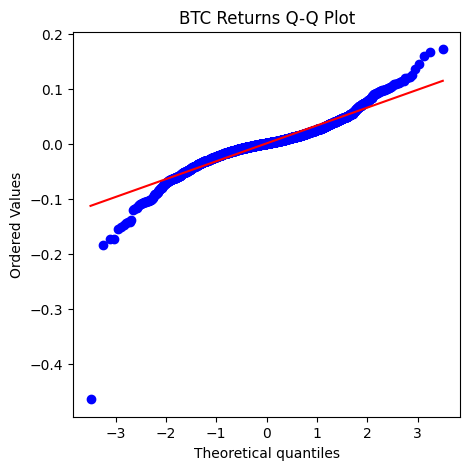

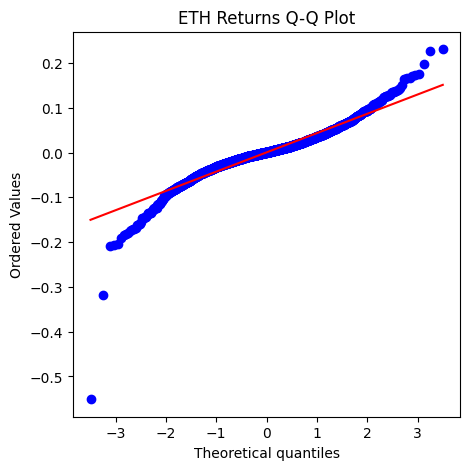

In [10]:
import scipy.stats as stats

plt.figure(figsize=(5, 5))
stats.probplot(returns["btc_usd_logret"], dist="norm", plot=plt)
plt.title("BTC Returns Q-Q Plot")
plt.show()

plt.figure(figsize=(5, 5))
stats.probplot(returns["eth_usd_logret"], dist="norm", plot=plt)
plt.title("ETH Returns Q-Q Plot")
plt.show()

## Interpretation:  
## Q–Q plots reveal that BTC and ETH returns deviate from normality in the tails, exhibiting heavy-tailed behavior. Extreme price moves occur more frequently than predicted by a Gaussian model, particularly for ETH.

## **Summary and Next Steps**

### **Key findings:**
### - BTC and ETH log returns are stationary in the mean but exhibit heavy tails and significant volatility clustering.
### - Autocorrelation in returns is weak, indicating limited linear predictability at the daily horizon.
### - Volatility is strongly time-varying, with ETH consistently more volatile than BTC.
### - Return distributions deviate from normality, particularly in the tails, reflecting realistic financial risk behavior.

### **Modeling implications:**  
### These diagnostics suggest that ARIMA-style models are appropriate as a baseline for capturing mean dynamics in returns, but strong forecasting power should not be expected given the near–white-noise structure of daily returns. The pronounced heteroskedasticity observed in both assets motivates extending the framework to explicitly model conditional volatility.


### **Next steps:**  
### - Fit separate ARIMA models to BTC and ETH log returns and evaluate out-of-sample forecasting performance.  
### - Extend the baseline with volatility model (ARIMA) to capture time-varying risk.  
### - Implement a rolling-window backtest to assess stability across market regimes.
